In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path_to_folder = r"C:\Users\clara\Desktop\special_course\ds003838"

subnums = np.arange(32, 99, 1)
subnums = np.delete(subnums, np.where((subnums == 37) | (subnums == 66) | (subnums == 94))) # remove subjects with missing data
subject_folders = [f'sub-0{i}' for i in subnums]


In [5]:
# Initialize an empty list to store DataFrames
all_subjects_events = []

for i in subject_folders:
    folder_path = os.path.join(path_to_folder, i, "pupil")
    filename = i + "_task-memory_events.tsv"
    file_path = os.path.join(folder_path, filename)

    # Read each CSV file into a DataFrame
    try:
        df = pd.read_csv(file_path, sep='\t', usecols=['timestamp', 'label'])
        all_subjects_events.append(df)
        
    except FileNotFoundError:
        print(f"File not found: {file_path}")

    except:
        print(file_path)

for i in all_subjects_events:
    print(i.head())

print(len(all_subjects_events))

      timestamp   label
0  1.603518e+09  500113
1  1.603518e+09  500213
2  1.603518e+09  500313
3  1.603518e+09  500413
4  1.603518e+09  500513
      timestamp   label
0  1.603534e+09  500105
1  1.603534e+09  500205
2  1.603534e+09  500305
3  1.603534e+09  500405
4  1.603534e+09  500505
      timestamp   label
0  1.603702e+09  500109
1  1.603702e+09  500209
2  1.603702e+09  500309
3  1.603702e+09  500409
4  1.603702e+09  500509
      timestamp   label
0  1.603783e+09  500109
1  1.603783e+09  500209
2  1.603783e+09  500309
3  1.603783e+09  500409
4  1.603783e+09  500509
      timestamp   label
0  1.603795e+09  500109
1  1.603795e+09  500209
2  1.603795e+09  500309
3  1.603795e+09  500409
4  1.603795e+09  500509
      timestamp   label
0  1.604041e+09  500109
1  1.604041e+09  500209
2  1.604041e+09  500309
3  1.604041e+09  500409
4  1.604041e+09  500509
      timestamp   label
0  1.604055e+09  500113
1  1.604055e+09  500213
2  1.604055e+09  500313
3  1.604055e+09  500413
4  1.604055e+09 

**For one subject:**
1. Pre processing
    - select data from the dominant eye
    - if conf. score <80%, NA
    - data broken into epochs corresponding to the time intervals starting 2s before the presentation of the first digit in the sequence and ending 3s after the presentation of the last digit in the sequence
    - MAD for rapid pupil size changes (if >16 std, NA)
    - Blinks [-100, 100] - NA
    - Trials with >50% NA - removed
    - Participants with <6 trials - removed
    - NA were linearly interpolated and smoothed with 5 points moving average
    - resulting pupil size was baseline normalized by subtracting the mean absolute value in the interval of 2 s before the presentation of the first digit in the sequence
2. Plotting 

3. Compare to thesis

In [6]:
# Load data of subject
sub = 1
subject_folder = subject_folders[sub]

folder_path = os.path.join(path_to_folder, subject_folder, "pupil")
filename = subject_folder + "_task-memory_pupil.tsv"
file_path = os.path.join(folder_path, filename)
  
# Read CSV file into a DataFrame
try:
    df = pd.read_csv(file_path, sep='\t', usecols=['pupil_timestamp', 'diameter', 'confidence', 'blink'])
    print(f"File loaded: {file_path}")
    
except FileNotFoundError:
    print(f"File not found: {file_path}")

except Error as e:
    print(f"{e} loading {file_path}")


File loaded: C:\Users\clara\Desktop\special_course\ds003838\sub-033\pupil\sub-033_task-memory_pupil.tsv


In [7]:
subject_pupil = df.copy()
print(subject_pupil.head(10))

   pupil_timestamp  confidence   diameter  blink
0     1.603534e+09    0.999805  29.931720      0
1     1.603534e+09    1.000000  29.932348      0
2     1.603534e+09    1.000000  31.640831      0
3     1.603534e+09    0.999497  31.638402      0
4     1.603534e+09    0.999897  30.347747      0
5     1.603534e+09    1.000000  30.347742      0
6     1.603534e+09    0.997627  32.117628      0
7     1.603534e+09    1.000000  32.123009      0
8     1.603534e+09    0.999573  30.667772      0
9     1.603534e+09    1.000000  30.667912      0


In [8]:
# NA for confidence below 80%
replaced_values = subject_pupil['confidence'] < 0.8
subject_pupil.loc[replaced_values, 'diameter'] = np.nan

# Count the number of replaced values
num_nan = replaced_values.sum()

In [9]:
# Print the result
print(f"{num_nan} out of {len(subject_pupil)} ({num_nan*100/len(subject_pupil)}%) values were replaced by NaN.")
print(subject_pupil.head(10))

1261471 out of 5798750 (21.75418840267299%) values were replaced by NaN.
   pupil_timestamp  confidence   diameter  blink
0     1.603534e+09    0.999805  29.931720      0
1     1.603534e+09    1.000000  29.932348      0
2     1.603534e+09    1.000000  31.640831      0
3     1.603534e+09    0.999497  31.638402      0
4     1.603534e+09    0.999897  30.347747      0
5     1.603534e+09    1.000000  30.347742      0
6     1.603534e+09    0.997627  32.117628      0
7     1.603534e+09    1.000000  32.123009      0
8     1.603534e+09    0.999573  30.667772      0
9     1.603534e+09    1.000000  30.667912      0


ChatGPT: Show the subject_pupil.head(10)) and the subj task memory events. Say that we want the data broken into epochs corresponding to the time intervals starting 2s before the presentation of the first digit in the sequence and ending 3s after the presentation of the last digit in the sequence. so we need to identify the timestamp of the first and last and make epochs. we probably want to difirientiate by load and by memory/load. 

dont average per subject. plot alll of the lines, maybe then i can plot an avarege line

In [49]:
import pandas as pd

# Helper to extract condition and load from a label string
def parse_label(label):
    label = str(label)
    condition = "control" if label.startswith("50") else "memory"
    load = int(label[4:6])  # 05, 09, 13
    return condition, load

def apply_speed_mad_filter(pupil_epoch, time_col="pupil_timestamp", signal_col="diameter", threshold_factor=16):
    # Compute time difference (in seconds)
    dt = np.diff(pupil_epoch[time_col], prepend=pupil_epoch[time_col].iloc[0])
    dt[dt <= 0] = np.nan  # Remove zero or negative dt to prevent spikes

    # Compute dilation speed: absolute change in diameter / time difference
    speed = np.abs(np.diff(pupil_epoch[signal_col], prepend=pupil_epoch[signal_col].iloc[0])) / dt
    # Mask speed where either signal or time was NaN
    nan_mask = pupil_epoch[signal_col].isna() | pd.isna(dt)
    speed[nan_mask] = np.nan

    # Compute MAD and median
    median_speed = np.nanmedian(speed)
    mad_speed = np.nanmedian(np.abs(speed - median_speed))

    # Threshold
    threshold = median_speed + threshold_factor * mad_speed

    # Invalidate points with too high speed
    pupil_epoch.loc[speed > threshold, signal_col] = np.nan

    return pupil_epoch

# Group consecutive labels belonging to the same trial
def group_trials(events_df):
    '''
    Group consecutive labels belonging to the same trial. Each trial is a sequence of digits (of length 5, 9 or 13),
    in either the control or memory condition
    Input:
        events_df: DataFrame with columns ["timestamp", "label"]
    Output:
        List of trials, where each trial is a tuple (condition, load, trial_rows), where
        - condition is either "control" or "memory"
        - load is the number of digits in the trial (5, 9 or 13)
        - trial_rows is a DataFrame with columns ["timestamp", "label", "condition", "load"] containing the rows of the trial
    '''
    # Ensure label is string for indexing
    events_df = events_df.copy()
    events_df["label"] = events_df["label"].astype(str)

    # Create a boolean mask for where new trials start (labels with digit 01)
    new_trial_mask = events_df["label"].str[2:4] == "01"

    # Assign trial numbers using cumulative sum of new trial indicators
    events_df["trial_id"] = new_trial_mask.cumsum()

    # Extract metadata: condition and load
    events_df["condition"] = np.where(events_df["label"].str.startswith("50"), "control", "memory")
    events_df["load"] = events_df["label"].str[4:6].astype(int)

    # Group by trial
    grouped = events_df.groupby("trial_id")

    # Collect trials as list of DataFrames with metadata
    trials = []
    for trial_id, group in grouped:
        condition = group["condition"].iloc[0]
        load = group["load"].iloc[0]
        trials.append((condition, load, group.drop(columns="trial_id")))

    return trials


# Create epochs
def create_epochs(subject_events, subject_pupil):
    subject_events = subject_events.sort_values("timestamp")
    trials = group_trials(subject_events)

    epochs = []

    for condition, load, trial_rows in trials:
        # Convert trial to DataFrame
        trial_df = pd.DataFrame(trial_rows)

        start_time = trial_df["timestamp"].iloc[0] - 2  # 2s before first digit
        end_time = trial_df["timestamp"].iloc[-1] + 3  # 3s after last digit

        # Select pupil data within this epoch
        pupil_epoch = subject_pupil[
            (subject_pupil["pupil_timestamp"] >= start_time) &
            (subject_pupil["pupil_timestamp"] <= end_time)
        ].copy()

        pupil_epoch["condition"] = condition
        pupil_epoch["load"] = load
        pupil_epoch["epoch_start"] = start_time
        pupil_epoch["epoch_end"] = end_time

        epochs.append(pupil_epoch)

    return epochs

# Create epochs and FILTER
def create_epochs_v2(subject_events, subject_pupil):
    subject_events = subject_events.sort_values("timestamp")
    trials = group_trials(subject_events)
    epochs = []

    for condition, load, trial_rows in trials:
        # Convert trial to DataFrame
        trial_df = pd.DataFrame(trial_rows)

        start_time = trial_df["timestamp"].iloc[0] - 2  # 2s before first digit
        end_time = trial_df["timestamp"].iloc[-1] + 3  # 3s after last digit

        # Select pupil data within this epoch
        pupil_epoch = subject_pupil[
            (subject_pupil["pupil_timestamp"] >= start_time) &
            (subject_pupil["pupil_timestamp"] <= end_time)
        ].copy()
        
        if pupil_epoch.empty:
            continue
        
        # Step 1: Apply Geller-style speed MAD filter. This is different from the thesis
        pupil_epoch = apply_speed_mad_filter(pupil_epoch)
        
        # Step 2: Handle blink: Set 'diameter' to NaN where blinks occur (±100ms)
        blink_times = pupil_epoch.loc[pupil_epoch['blink'] == 1, 'pupil_timestamp'].values
        if len(blink_times) > 0:
            ts = pupil_epoch['pupil_timestamp'].values[:, np.newaxis]
            in_blink = ((ts >= blink_times - 0.1) & (ts <= blink_times + 0.1)).any(axis=1)
            pupil_epoch.loc[in_blink, 'diameter'] = np.nan
        
        # Step 3: Remove trial if more than 50% missing
        missing_ratio = pupil_epoch["diameter"].isna().mean()
        if missing_ratio > 0.5:
            continue
        
        # Step 4: Interpolate and smooth
        pupil_epoch["diameter"] = pupil_epoch["diameter"].interpolate(method="linear", limit_direction="both")
        pupil_epoch["diameter"] = pupil_epoch["diameter"].rolling(window=5, center=True, min_periods=1).mean()
        
        # Convert timestamp (in seconds) to datetime for resampling
        pupil_epoch['pupil_timestamp'] = pd.to_datetime(pupil_epoch['pupil_timestamp'], unit='s')

        # Step 5: Baseline normalization using 2s before first digit
        start_time = pupil_epoch['pupil_timestamp'].min()
        baseline_interval = pupil_epoch[(pupil_epoch['pupil_timestamp'] >= start_time) & 
                                    (pupil_epoch['pupil_timestamp'] < start_time + pd.Timedelta(seconds=2))]
        
        # Compute the mean of pupil size during the baseline interval
        baseline_mean = baseline_interval['diameter'].mean()
        pupil_epoch["diameter"] = pupil_epoch["diameter"] - baseline_mean
        
        pupil_epoch.set_index('pupil_timestamp', inplace=True)
        # Step 5: Resample by using a time-based approach (10 Hz = one data point every 100ms)
        pupil_epoch = pupil_epoch.resample("100ms").mean()

        # Fill any NaNs created during resampling
        pupil_epoch["diameter"] = pupil_epoch["diameter"].ffill().bfill()

        # Add metadata
        pupil_epoch["condition"] = condition
        pupil_epoch["load"] = load
        pupil_epoch["epoch_start"] = start_time
        pupil_epoch["epoch_end"] = end_time

        epochs.append(pupil_epoch)
        
    return epochs

In [38]:
subject_events = all_subjects_events[sub]
print(subject_events.head(10))

      timestamp   label
0  1.603534e+09  500105
1  1.603534e+09  500205
2  1.603534e+09  500305
3  1.603534e+09  500405
4  1.603534e+09  500505
5  1.603534e+09  500113
6  1.603534e+09  500213
7  1.603534e+09  500313
8  1.603534e+09  500413
9  1.603534e+09  500513


In [44]:
trials = group_trials(subject_events)

[('control', 5, [timestamp    1.603534e+09
label        5.001050e+05
Name: 0, dtype: float64, timestamp    1.603534e+09
label        5.002050e+05
Name: 1, dtype: float64, timestamp    1.603534e+09
label        5.003050e+05
Name: 2, dtype: float64, timestamp    1.603534e+09
label        5.004050e+05
Name: 3, dtype: float64, timestamp    1.603534e+09
label        5.005050e+05
Name: 4, dtype: float64]), ('control', 13, [timestamp    1.603534e+09
label        5.001130e+05
Name: 5, dtype: float64, timestamp    1.603534e+09
label        5.002130e+05
Name: 6, dtype: float64, timestamp    1.603534e+09
label        5.003130e+05
Name: 7, dtype: float64, timestamp    1.603534e+09
label        5.004130e+05
Name: 8, dtype: float64, timestamp    1.603534e+09
label        5.005130e+05
Name: 9, dtype: float64, timestamp    1.603534e+09
label        5.006130e+05
Name: 10, dtype: float64, timestamp    1.603534e+09
label        5.007130e+05
Name: 11, dtype: float64, timestamp    1.603534e+09
label       

In [ ]:
epochs = create_epochs_v2(subject_events, subject_pupil)
if len(epochs) < 6: #the meximum should be 162 epochs (3+12+3)*9
    print("⚠️ Subject excluded: too few valid trials")
# Example: print the first epoch
print(epochs[0].head())

# Or concatenate them all for plotting or analysis
all_epochs_df = pd.concat(epochs, ignore_index=True)


                         confidence  diameter  blink condition  load  \
pupil_timestamp                                                        
2020-10-24 10:01:58.700    0.998312 -0.404323    0.0   control     5   
2020-10-24 10:01:58.800    0.999456 -0.382254    0.0   control     5   
2020-10-24 10:01:58.900    0.995445 -0.537769    0.0   control     5   
2020-10-24 10:01:59.000    0.999670 -0.640171    0.0   control     5   
2020-10-24 10:01:59.100    0.995727 -0.454598    0.0   control     5   

                                          epoch_start     epoch_end  
pupil_timestamp                                                      
2020-10-24 10:01:58.700 2020-10-24 10:01:58.739269972  1.603534e+09  
2020-10-24 10:01:58.800 2020-10-24 10:01:58.739269972  1.603534e+09  
2020-10-24 10:01:58.900 2020-10-24 10:01:58.739269972  1.603534e+09  
2020-10-24 10:01:59.000 2020-10-24 10:01:58.739269972  1.603534e+09  
2020-10-24 10:01:59.100 2020-10-24 10:01:58.739269972  1.603534e+09  


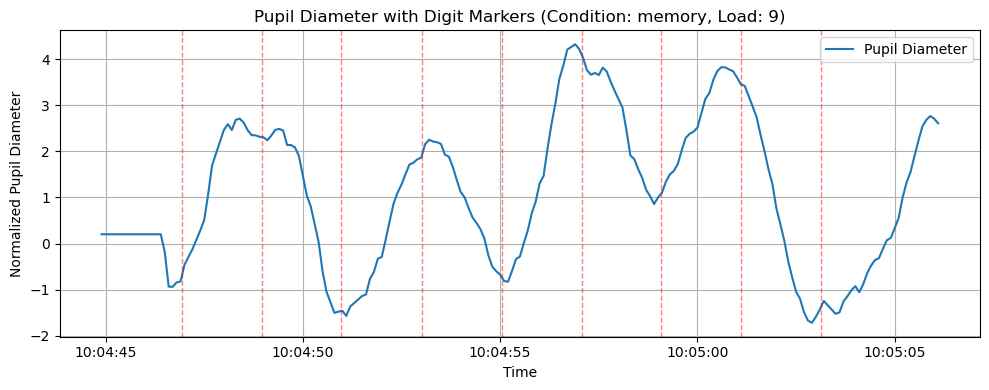

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# Pick one epoch and its corresponding trial
epoch = epochs[5]
trial = trials[5][2]  # trials[0] = (condition, load, trial_df)

# Convert digit times to datetime
digit_times = pd.to_datetime(pd.DataFrame(trial)["timestamp"], unit="s")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(epoch.index, epoch["diameter"], label="Pupil Diameter")

# Plot digit onsets
for t in digit_times:
    plt.axvline(t, color="red", linestyle="--", linewidth=1, alpha=0.5)

# Labels and legend
plt.title(f"Pupil Diameter with Digit Markers (Condition: {epoch['condition'].iloc[0]}, Load: {epoch['load'].iloc[0]})")
plt.xlabel("Time")
plt.ylabel("Normalized Pupil Diameter")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**For all subjects:**
1. Do the mean
2. Plot